# 〽️ Polynomial Regression

In this notebook, we'll explore **Polynomial Regression** using the `FuelConsumptionCo2.csv` dataset. This dataset contains information on vehicle fuel consumption and CO₂ emissions for various car models.

<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2011/Session%2011_2%20-%20Polynomial%20Regression.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2011/Session%2011_2%20-%20Polynomial%20Regression.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

We'll start by importing the dataset and performing some initial exploration to understand its structure.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


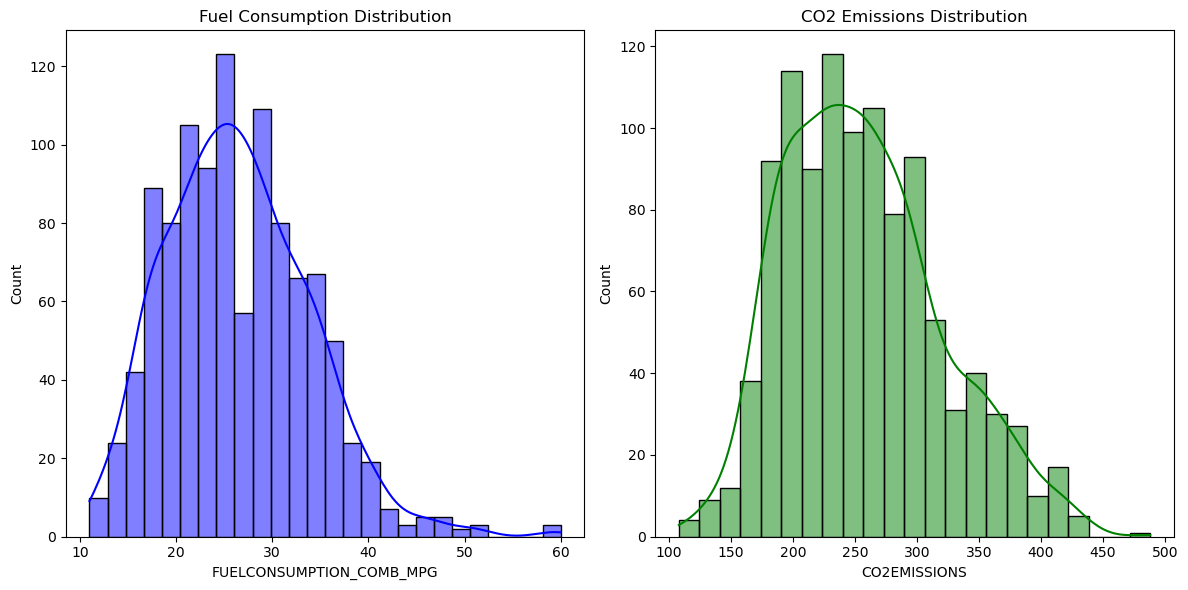

In [4]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['FUELCONSUMPTION_COMB_MPG'], kde=True, color='blue')
plt.title('Fuel Consumption Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['CO2EMISSIONS'], kde=True, color='green')
plt.title('CO2 Emissions Distribution')

plt.tight_layout()

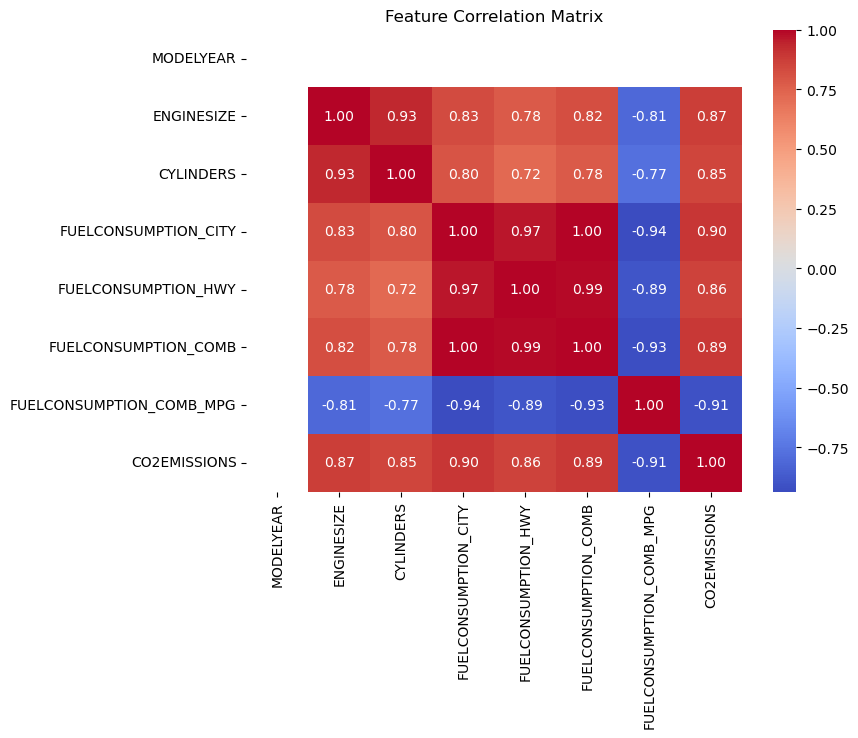

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [6]:
cdf = df[['ENGINESIZE','FUELCONSUMPTION_COMB','FUELCONSUMPTION_COMB_MPG','CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,8.5,33,196
1,2.4,9.6,29,221
2,1.5,5.9,48,136
3,3.5,11.1,25,255
4,3.5,10.6,27,244


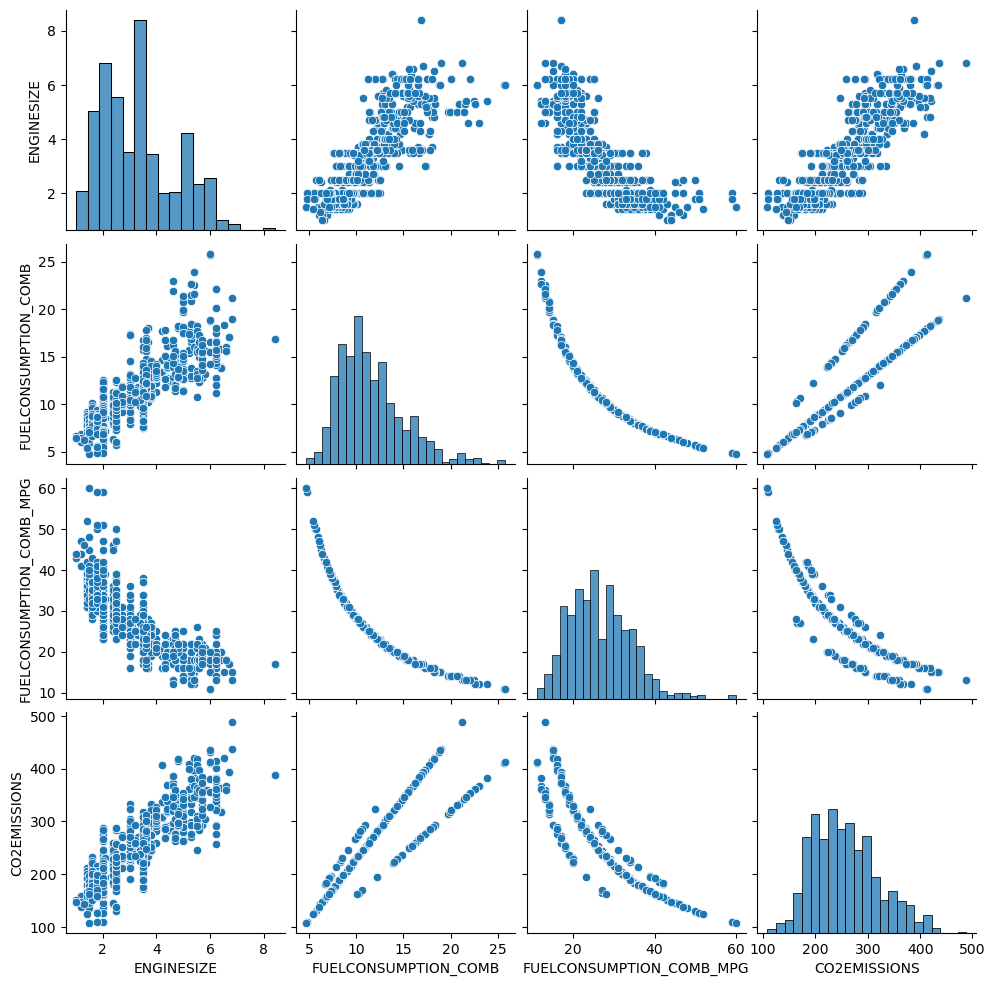

In [7]:
sns.pairplot(cdf)

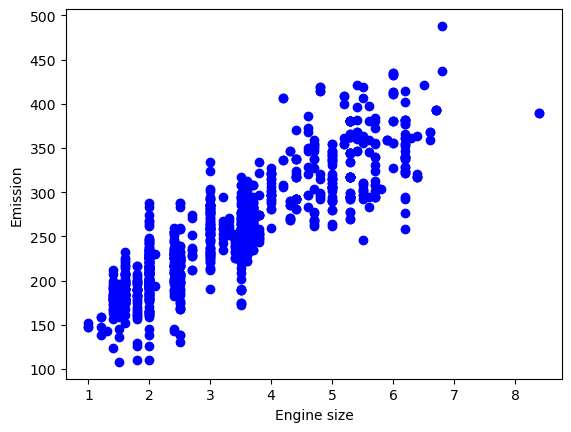

In [8]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

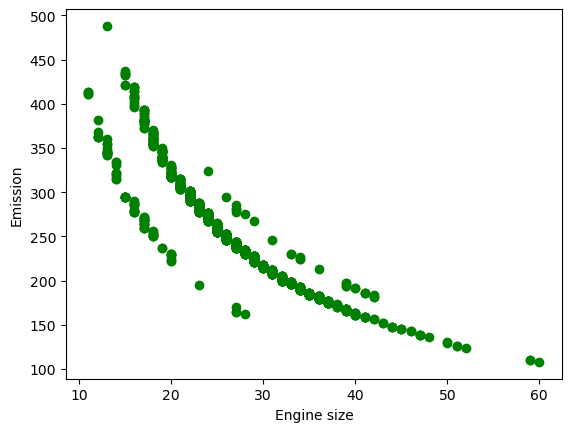

In [9]:
plt.scatter(cdf.FUELCONSUMPTION_COMB_MPG, cdf.CO2EMISSIONS,  color='green')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

## Creating train and test dataset

In [10]:
from sklearn.model_selection import train_test_split

X = cdf[['ENGINESIZE', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG']]
y = cdf['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape, y_train.shape)
print("Testing set size:", X_test.shape, y_test.shape)


# msk = np.random.rand(len(df)) < 0.8
# train = cdf[msk]
# test = cdf[~msk]

Training set size: (853, 3) (853,)
Testing set size: (214, 3) (214,)


## 📈 Polynomial Regression Model

### 🔢 **What is Polynomial Regression?**

Polynomial regression is an extension of linear regression where the relationship between the independent variable $x$ and the dependent variable $y$ is modeled as an $n$-th degree polynomial:

$$
y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_n x^n + \varepsilon
$$

For example, for a **second-degree polynomial (quadratic)**:

$$
y = \beta_0 + \beta_1 x + \beta_2 x^2
$$

This allows us to model **non-linear relationships** between variables.

---
### 📚 What is `PolynomialFeatures`?

`PolynomialFeatures` is a preprocessing class from `sklearn.preprocessing` used to **generate polynomial and interaction features** from input data.

It **transforms** your original feature(s) into a new feature matrix consisting of **all polynomial combinations** up to a specified degree.

This is essential for **Polynomial Regression**, where you want to model non-linear relationships by introducing higher-order terms like $x^2$, $x^3$, etc.

---

#### ⚙️ Parameters of `PolynomialFeatures`


| Parameter              | Description                                                                                                                                       |
| ---------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`degree`**           | The **maximum degree** of the polynomial features. For example, `degree=2` will create $x$, $x^2$ terms.                                          |
| **`include_bias`**     | If `True`, adds a column of **ones** to represent the **bias (intercept) term**. Default is `True`.                                               |
| **`interaction_only`** | If `True`, only interaction features are produced (no powers like $x^2$, only combinations like $x_1 \cdot x_2$). Usually `False` for regression. |

---

### 🛠️ `fit_transform(X)`

This method is used to:

1. **Fit** the transformer to the data (find structure and shape)
2. **Transform** the original features into a polynomial feature set

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

train_x = np.asanyarray(X_train[['FUELCONSUMPTION_COMB_MPG']])
train_y = np.asanyarray(y_train)

test_x = np.asanyarray(X_test[['FUELCONSUMPTION_COMB_MPG']])
test_y = np.asanyarray(y_test)

poly = PolynomialFeatures(degree=2)
train_x_poly = poly.fit_transform(train_x)

print(train_x_poly[:5])

[[1.000e+00 3.600e+01 1.296e+03]
 [1.000e+00 2.200e+01 4.840e+02]
 [1.000e+00 2.900e+01 8.410e+02]
 [1.000e+00 2.500e+01 6.250e+02]
 [1.000e+00 1.700e+01 2.890e+02]]


**fit_transform** takes our x values, and output a list of our data raised from power of 0 to power of 2 (since we set the degree of our polynomial to 2).   

The equation and the sample example is displayed below.   


$$
\begin{bmatrix}
    v_1\\\\
    v_2\\\\
    \vdots\\\\
    v_n
\end{bmatrix}\longrightarrow \begin{bmatrix}
    [ 1 & v_1 & v_1^2]\\\\
    [ 1 & v_2 & v_2^2]\\\\
    \vdots & \vdots & \vdots\\\\
    [ 1 & v_n & v_n^2]
\end{bmatrix}
$$




$$
\begin{bmatrix}
    2.\\\\
    2.4\\\\
    1.5\\\\
    \vdots
\end{bmatrix} \longrightarrow \begin{bmatrix}
    [ 1 & 2. & 4.]\\\\
    [ 1 & 2.4 & 5.76]\\\\
    [ 1 & 1.5 & 2.25]\\\\
    \vdots & \vdots & \vdots\\\\
\end{bmatrix}
$$







It looks like feature sets for multiple linear regression analysis, right? Yes. It Does. 
Indeed, Polynomial regression is a special case of linear regression, with the main idea of how do you select your features. Just consider replacing the  $x$ with $x_1$, $x_1^2$ with $x_2$, and so on. Then the 2nd degree equation would be turn into:

$$y = b + \theta_1  x_1 + \theta_2 x_2$$

Now, we can deal with it as a 'linear regression' problem. Therefore, this polynomial regression is considered to be a special case of traditional multiple linear regression. So, you can use the same mechanism as linear regression to solve such problems. 



so we can use __LinearRegression()__ function to solve it:


In [12]:
clf = linear_model.LinearRegression()
train_y_ = clf.fit(train_x_poly, train_y)
# The coefficients
print ('Coefficients: ', clf.coef_)
print ('Intercept: ',clf.intercept_)

Coefficients:  [  0.         -15.07165228   0.12895688]
Intercept:  557.5150235580732


As mentioned before, __Coefficient__ and __Intercept__ , are the parameters of the fit curvy line. 
Given that it is a typical multiple linear regression, with 3 parameters, and knowing that the parameters are the intercept and coefficients of hyperplane, sklearn has estimated them from our new set of feature sets. Lets plot it:


Text(0, 0.5, 'Emission')

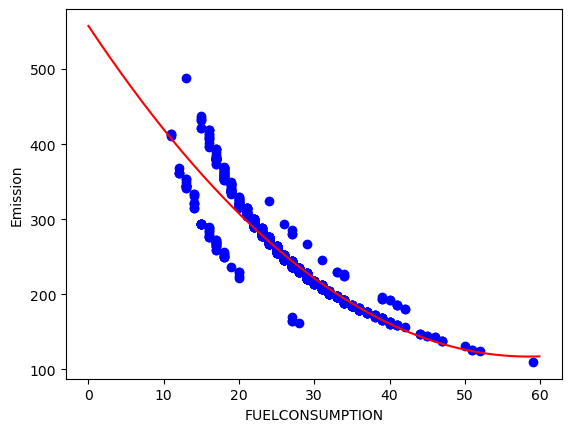

In [15]:
plt.scatter(train_x, train_y,  color='blue')
XX = np.arange(0.0, 60.0, 0.1)
yy = clf.intercept_ + clf.coef_[1] * XX + clf.coef_[2] * np.power(XX, 2)

plt.plot(XX, yy, '-r' )
plt.xlabel("FUELCONSUMPTION")
plt.ylabel("Emission")

In [17]:
test_x_poly = poly.transform(test_x)
test_y_pred = clf.predict(test_x_poly)

<h2 id="evaluation">Evaluation</h2>


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(test_y, test_y_pred)
mse = mean_squared_error(test_y, test_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, test_y_pred)

print("Mean Absolute Error (MAE): %.2f" % mae)
print("Mean Squared Error (MSE): %.2f" % mse)
print("Root Mean Squared Error (RMSE): %.2f" % rmse)
print("R² Score: %.2f" % r2)

Mean Absolute Error (MAE): 13.16
Mean Squared Error (MSE): 556.37
Root Mean Squared Error (RMSE): 23.59
R² Score: 0.87


<h2 id="practice">Practice</h2>
Try to use a polynomial regression with the dataset but this time with degree three (cubic). Does it result in better accuracy?


# Good Job!


<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2011/Session%2011_3%20-%20Seaborn%20Project.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>
